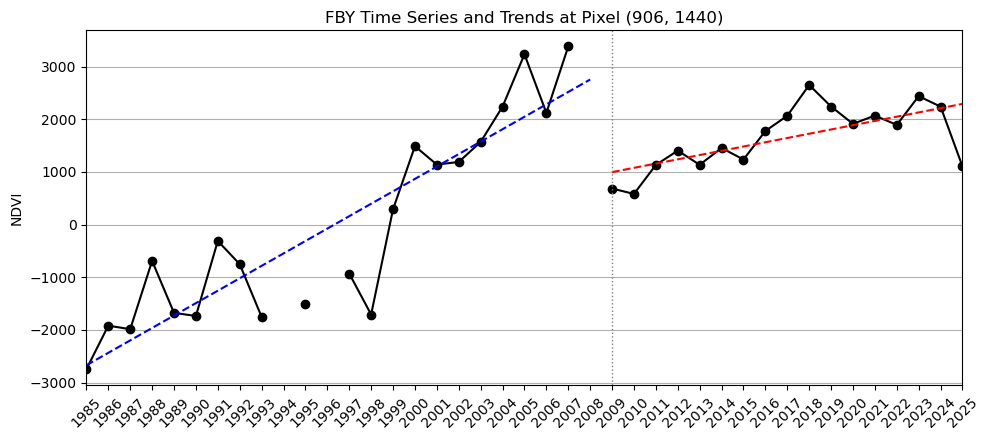

In [78]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Paths
ndvi_raster_path = "/mnt/intenso/masterarbeit/landsat/tsa2/max/19850101-20251231_001-365_HL_TSA_LNDLG_NDV_FBY.tif"
params_raster_path = "/mnt/intenso/masterarbeit/landsat/tsa2/max/19850101-20251231_001-365_HL_TSA_LNDLG_NDV_CAY.tif"

# Pixel location
row, col = 906, 1440

# Load NDVI time series
with rasterio.open(ndvi_raster_path) as src:
    nodata_value = src.nodata
    time_labels = [d[5:] for d in src.descriptions]
    years = np.array([int(label[:4]) for label in time_labels])
    ndvi_values = [src.read(i)[row, col] for i in range(1, src.count + 1)]

ndvi_series = np.array(ndvi_values, dtype='float32')
ndvi_series[ndvi_series == nodata_value] = np.nan

# Load parameters from metrics raster
with rasterio.open(params_raster_path) as src:
    def get_band_val(band):
        val = src.read(band)[row, col]
        return val if val != -9999 else np.nan

    # Trend parameters
    before_slope = get_band_val(18)
    before_offset = get_band_val(17)
    after_slope = get_band_val(30)
    after_offset = get_band_val(29)
    year_of_change = get_band_val(3)

    # Metrics
    change = get_band_val(1)
    loss = get_band_val(2)
    before_mean = get_band_val(16)
    before_rsq = get_band_val(21)
    after_mean = get_band_val(28)
    after_rsq = get_band_val(33)

# Create masks
before_mask = years < year_of_change if not np.isnan(year_of_change) else np.full_like(years, False, dtype=bool)
after_mask = years >= year_of_change if not np.isnan(year_of_change) else np.full_like(years, False, dtype=bool)

# Compute trend lines
trend_before = np.full_like(years, np.nan, dtype='float32')
trend_after = np.full_like(years, np.nan, dtype='float32')

if not np.isnan(before_slope) and not np.isnan(before_offset):
    trend_before[before_mask] = before_slope * (years[before_mask] - years[0]) + before_offset

if not np.isnan(after_slope) and not np.isnan(after_offset) and not np.isnan(year_of_change):
    trend_after[after_mask] = after_slope * (years[after_mask] - year_of_change) + after_offset

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, ndvi_series, marker='o', linestyle='-', label='NDVI', color='black')

if not np.all(np.isnan(trend_before)):
    plt.plot(years, trend_before, linestyle='--', label='Before Trend', color='blue')
if not np.all(np.isnan(trend_after)):
    plt.plot(years, trend_after, linestyle='--', label='After Trend', color='red')

# Add vertical line at year of change
if not np.isnan(year_of_change):
    plt.axvline(x=year_of_change, color='gray', linestyle=':', linewidth=1)
    # plt.text(year_of_change + 0.2, plt.ylim()[0] + 0.02, int(year_of_change),
    #          rotation=90, color='gray', verticalalignment='bottom')

plt.xticks(ticks=years ,rotation=45)
# plt.xlabel("Year")
plt.ylabel("NDVI")
plt.title(f"FBY Time Series and Trends at Pixel ({row}, {col})")
plt.grid(axis='y')
plt.margins(x=0)
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space below

# Add metrics below the plot
if all(not np.isnan(x) for x in [change, loss, before_mean, before_rsq, after_mean, after_rsq]):
    metrics_text = (
        f"Change: {change}             Loss: {loss}\n"
        f"Before Mean: {before_mean}        R²: {before_rsq}\n"
        f"After Mean:  {after_mean}       R²: {after_rsq}"
    )
else:
    metrics_text = "Metrics not available"

# plt.figtext(0.5, 0.04, metrics_text, wrap=True, ha='left', fontsize=10)

plt.show()


In [11]:
# Basic deps
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
from affine import Affine
from tqdm import tqdm
import warnings

# -------------------------
# CONFIG
# -------------------------
# Reference Landsat/CAT raster (defines 30 m grid, transform, shape, CRS = EPSG:28992)
REF_RASTER = Path("/mnt/intenso/masterarbeit/landsat/tsa_full/CAY/MAX_NDV_CAY.tif")

# BAG buildings with construction year attribute
BAG_PATH = Path("/mnt/intenso/masterarbeit/vector/buildings/buildings_reviewed/reviewed_buildings.gpkg")
BAG_LAYER = 'classified_buildings'
BAG_YEAR_COL = "oorspronkelijkBouwjaar"  

# Output
OUT_RASTER = Path("/mnt/intenso/masterarbeit/landsat/BAG_year_30m_tau050.tif")

# Year bounds
MIN_YEAR = 1982
MAX_YEAR = 2023

# Area-fraction threshold τ (0..1): first year when cumulative built fraction >= τ
TAU = 0.3

# Fine grid factor (3 m if 30 m / 10). Must divide pixel size evenly.
FINE_FACTOR = 10  # 30m / 10 = 3m

# Rasterize behavior
ALL_TOUCHED = True  # True makes rasterization more inclusive at edges
DISSOLVE_BY_YEAR = False  # True: unary_union per year (slower upfront, faster rasterize)

# Optional: pre-filter very small buildings (area in m^2) that won’t influence 30 m pixels
MIN_BUILDING_AREA = 5.0  # e.g. 5 m²; set 0 to disable

warnings.filterwarnings("ignore", category=UserWarning)


In [12]:
with rio.open(REF_RASTER) as ref:
    ref_meta = ref.meta.copy()
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height
    ref_dtype = "int16"  # we will write years as int16
    ref_nodata = 0

# Derive fine grid aligned to reference (pixel size / FINE_FACTOR)
# affine: x' = a*x + b*y + c; y' = d*x + e*y + f
fine_transform = ref_transform * Affine.scale(1 / FINE_FACTOR, 1 / FINE_FACTOR)
fine_width = ref_width * FINE_FACTOR
fine_height = ref_height * FINE_FACTOR

# Sanity: print pixel sizes
px_size_x = ref_transform.a
px_size_y = -ref_transform.e
print(f"Coarse pixel size: {px_size_x:.3f} m x {px_size_y:.3f} m")
print(f"Fine pixel size:   {fine_transform.a:.3f} m x {-fine_transform.e:.3f} m")
print(f"Coarse grid: {ref_width}×{ref_height}, Fine grid: {fine_width}×{fine_height}")


Coarse pixel size: 30.000 m x 30.000 m
Fine pixel size:   3.000 m x 3.000 m
Coarse grid: 3000×2000, Fine grid: 30000×20000


In [13]:
# Load BAG
bag = gpd.read_file(BAG_PATH, layer=BAG_LAYER) if BAG_LAYER else gpd.read_file(BAG_PATH)

# Ensure CRS matches
assert str(bag.crs) == str(ref_crs), f"CRS mismatch: BAG {bag.crs} vs ref {ref_crs}"

# Keep valid years
bag = bag[bag[BAG_YEAR_COL].notna()].copy()
bag[BAG_YEAR_COL] = bag[BAG_YEAR_COL].astype(int)
bag = bag[(bag[BAG_YEAR_COL] >= MIN_YEAR) & (bag[BAG_YEAR_COL] <= MAX_YEAR)].copy()

# Optional: filter tiny polygons unlikely to affect 30 m pixels
if MIN_BUILDING_AREA and MIN_BUILDING_AREA > 0:
    bag["area_m2"] = bag.geometry.area
    bag = bag[bag["area_m2"] >= MIN_BUILDING_AREA].copy()
    bag = bag.drop(columns=["area_m2"])

years_sorted = np.sort(bag[BAG_YEAR_COL].unique())
print(f"Years in BAG within range [{MIN_YEAR}, {MAX_YEAR}]: {years_sorted[:10]} ... total {len(years_sorted)}")
print(f"Total buildings: {len(bag):,}")


Years in BAG within range [1982, 2023]: [1982 1983 1984 1985 1986 1987 1988 1989 1990 1991] ... total 42
Total buildings: 284,000


In [14]:
if DISSOLVE_BY_YEAR:
    # Build dict: year -> MultiPolygon/GeometryCollection (unary_union)
    from shapely.ops import unary_union

    dissolved = {}
    for y in tqdm(years_sorted, desc="Dissolve by year"):
        geoms = bag.loc[bag[BAG_YEAR_COL] == y, "geometry"].tolist()
        if len(geoms) == 0:
            continue
        dissolved[y] = unary_union(geoms)
else:
    dissolved = None


In [15]:
def block_mean(arr_bool, factor):
    """
    arr_bool: 2D boolean or {0,1} array at fine resolution
    Returns a float32 array at coarse resolution with per-block mean (fraction).
    """
    Hf, Wf = arr_bool.shape
    Hc = Hf // factor
    Wc = Wf // factor
    # reshape to (Hc, factor, Wc, factor) and mean over the 2 fine axes
    out = arr_bool.reshape(Hc, factor, Wc, factor).mean(axis=(1, 3)).astype(np.float32)
    return out


In [16]:
# Output coarse year raster (int16), 0 = no assignment
out_year = np.zeros((ref_height, ref_width), dtype=np.int16)

# Cumulative fine mask
cum_mask_fine = np.zeros((fine_height, fine_width), dtype=np.uint8)  # 0/1

# Iterate through years in ascending order
for y in tqdm(years_sorted, desc="Year loop"):

    # 1) Rasterize buildings constructed exactly in year y onto fine grid (0/1)
    if dissolved is not None:
        geoms = [dissolved[y]] if y in dissolved else []
    else:
        geoms = bag.loc[bag[BAG_YEAR_COL] == y, "geometry"].tolist()

    if len(geoms) == 0:
        continue

    year_mask_fine = rasterize(
        [(geom, 1) for geom in geoms],
        out_shape=(fine_height, fine_width),
        transform=fine_transform,
        fill=0,
        all_touched=ALL_TOUCHED,
        dtype="uint8",
    )

    # 2) Update cumulative built mask (<= y)
    # Any pixel that becomes built in year y stays built thereafter
    np.bitwise_or(cum_mask_fine, year_mask_fine, out=cum_mask_fine)

    # 3) Compute coarse fraction for current cumulative mask
    cum_frac_coarse = block_mean(cum_mask_fine, FINE_FACTOR)  # float32 in [0,1]

    # 4) Assign earliest year where fraction >= tau, only for currently unassigned pixels
    unassigned = (out_year == 0)
    meets_tau = (cum_frac_coarse >= TAU)
    newly_assigned = unassigned & meets_tau
    out_year[newly_assigned] = np.int16(y)

# Done
print("Assigned pixels:", np.count_nonzero(out_year))


Year loop: 100%|██████████| 42/42 [00:41<00:00,  1.00it/s]

Assigned pixels: 71028


In [17]:
meta = ref_meta.copy()
meta.update(
    count=1,
    dtype="int16",
    nodata=ref_nodata
)

OUT_RASTER.parent.mkdir(parents=True, exist_ok=True)
with rio.open(OUT_RASTER, "w", **meta) as dst:
    dst.write(out_year, 1)

print(OUT_RASTER)


/mnt/intenso/masterarbeit/landsat/BAG_year_30m_tau050.tif


In [18]:
vals = out_year[out_year > 0]
print(f"Non-zero pixels: {vals.size:,}")
if vals.size:
    print(f"Year range: {vals.min()}..{vals.max()}")
    # Simple histogram
    unique, counts = np.unique(vals, return_counts=True)
    for u, c in zip(unique[:20], counts[:20]):  # print first 20
        print(u, c)


Non-zero pixels: 71,028
Year range: 1982..2023
1982 1790
1983 1403
1984 1677
1985 1505
1986 1445
1987 1748
1988 2372
1989 2522
1990 2673
1991 2083
1992 2415
1993 2154
1994 1582
1995 2571
1996 1884
1997 2446
1998 2288
1999 1800
2000 2380
2001 2377
